In [135]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime as dt 
from PIL import Image
from matplotlib.ticker import MultipleLocator

In [136]:
#reading file
df = pd.read_csv("spotify_churn_dataset.csv")
df = df.drop(columns = ["user_id"])
df.head(10)


,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
5,Female,17,AU,Free,219,35,0.46,Desktop,13,0,0
6,Female,39,UK,Premium,289,44,0.38,Desktop,0,1,0
7,Female,41,UK,Free,210,68,0.11,Mobile,5,0,0
8,Other,55,DE,Student,50,66,0.29,Web,0,1,0
9,Male,44,DE,Free,278,94,0.38,Mobile,44,0,0


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 8000 non-null   object 
 1   age                    8000 non-null   int64  
 2   country                8000 non-null   object 
 3   subscription_type      8000 non-null   object 
 4   listening_time         8000 non-null   int64  
 5   songs_played_per_day   8000 non-null   int64  
 6   skip_rate              8000 non-null   float64
 7   device_type            8000 non-null   object 
 8   ads_listened_per_week  8000 non-null   int64  
 9   offline_listening      8000 non-null   int64  
 10  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 687.6+ KB


In [138]:
df.columns

Index(['gender', 'age', 'country', 'subscription_type', 'listening_time',
       'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

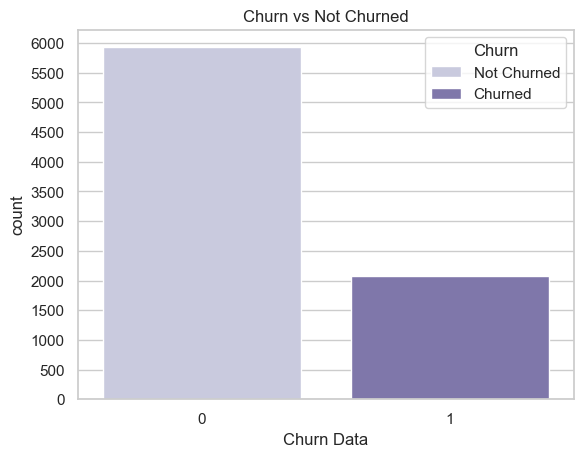

In [139]:
#Churned vs Not Churned
gr=sns.countplot(data=df,x='is_churned',palette='Purples',hue='is_churned')
plt.title('Churn vs Not Churned')
plt.xlabel('Churn Data')
label5=['Not Churned','Churned']
gr.legend(title='Churn',labels=label5)
plt.gca().yaxis.set_major_locator(MultipleLocator(500))

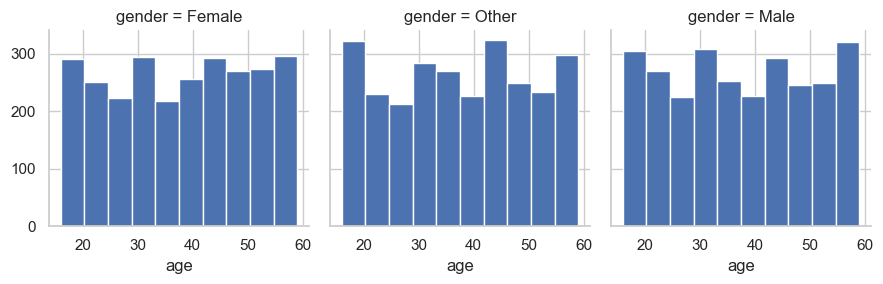

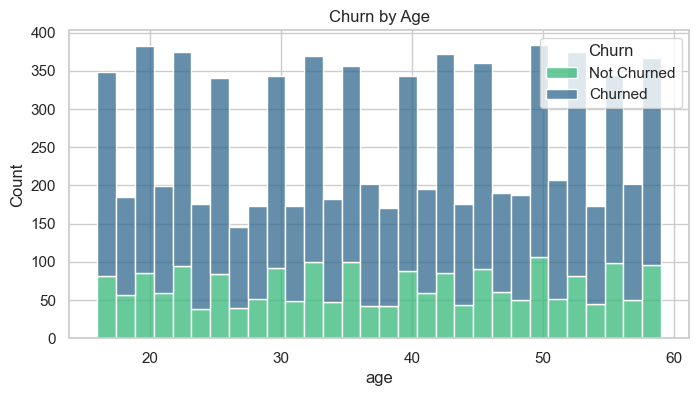

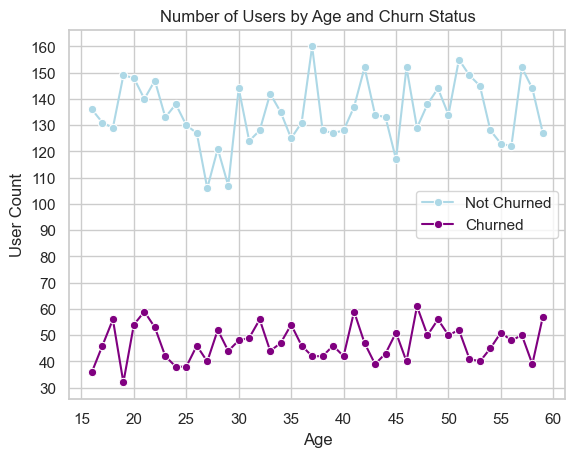

In [140]:
#Churn By Age
sns.FacetGrid(data=df,col='gender').map(plt.hist,'age')

plt.figure(figsize=(8,4))
gr=sns.histplot(data=df,x='age',hue='is_churned',multiple='stack',bins=30,palette='viridis')
plt.title('Churn by Age')
label5=['Not Churned','Churned']
gr.legend(title='Churn',labels=label5)
plt.show()

churnbyage = df.groupby(['age', 'is_churned']).size().unstack(fill_value=0)
sns.lineplot(x=churnbyage.index,y=churnbyage[0], marker='o',label='Not Churned', color='lightblue')
sns.lineplot(x=churnbyage.index,y=churnbyage[1], marker='o',label='Churned', color='purple')
plt.title("Number of Users by Age and Churn Status")
plt.xlabel("Age")
plt.ylabel("User Count")

plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.gca().yaxis.set_major_locator(MultipleLocator(10))

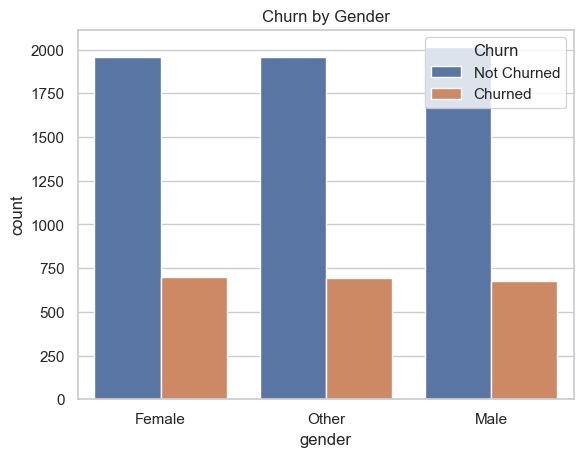

In [141]:
#Churn By Gender
gr=sns.countplot(data=df,x='gender',hue='is_churned')
plt.title("Churn by Gender")           
label5=['Not Churned','Churned']
gr.legend(title='Churn',labels=label5)

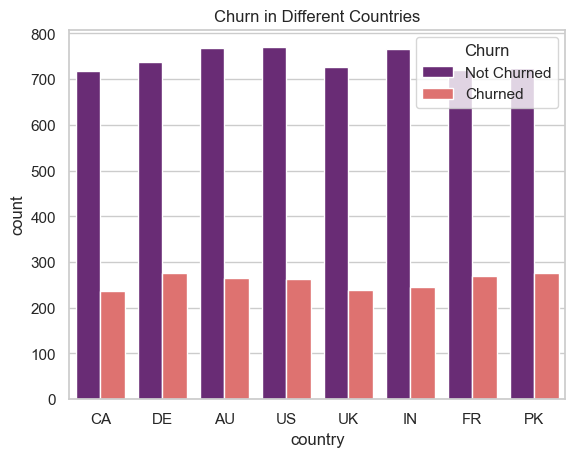

In [142]:
#Churn By Country
countries=df['country'].value_counts().head(10).index
gr=sns.countplot(data=df[df['country'].isin(countries)],x='country',hue='is_churned',palette='magma')
plt.title("Churn in Different Countries")
label5=['Not Churned','Churned']
gr.legend(title='Churn',labels=label5)
plt.show()

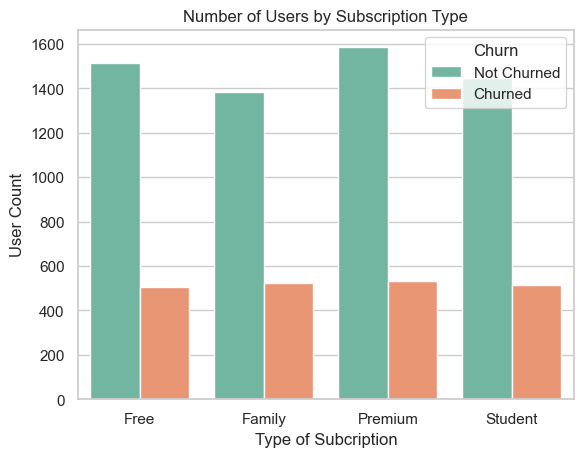

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt
gr=sns.countplot(data=df, x='subscription_type', palette='Set2', hue='is_churned')
plt.title("Number of Users by Subscription Type")
plt.xlabel("Type of Subcription")
plt.ylabel("User Count")

label5=['Not Churned','Churned']
gr.legend(title='Churn',labels=label5)
plt.show()
